## AI-Based Manufacturing Efficiency Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset

In [2]:
df = pd.read_csv("Thales_Group_Manufacturing.csv")
df.head()

,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,01-01-2025,00:00:00,39,Idle,74.138,3.501,8.612,10.651,0.208,7.751,477.657,0.345,14.965,Low
1,01-01-2025,00:01:00,29,Active,84.265,3.356,2.269,29.112,2.228,4.989,398.175,0.770,7.678,Low
2,01-01-2025,00:02:00,15,Active,44.280,2.080,6.144,18.357,1.639,0.457,108.075,0.987,8.198,Low
3,01-01-2025,00:03:00,43,Active,40.569,0.298,4.068,29.154,1.161,4.583,329.579,0.983,2.741,Medium
4,01-01-2025,00:04:00,8,Idle,75.064,0.346,6.226,34.029,4.797,2.288,159.114,0.573,12.101,Low


## Exploratory Data Analysis (EDA)

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           100000 non-null  object 
 1   Timestamp                      100000 non-null  object 
 2   Machine_ID                     100000 non-null  int64  
 3   Operation_Mode                 100000 non-null  object 
 4   Temperature_C                  100000 non-null  float64
 5   Vibration_Hz                   100000 non-null  float64
 6   Power_Consumption_kW           100000 non-null  float64
 7   Network_Latency_ms             100000 non-null  float64
 8   Packet_Loss_%                  100000 non-null  float64
 9   Quality_Control_Defect_Rate_%  100000 non-null  float64
 10  Production_Speed_units_per_hr  100000 non-null  float64
 11  Predictive_Maintenance_Score   100000 non-null  float64
 12  Error_Rate_%                   

Date                             0
Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64

## Data Preprocessing

In [4]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Timestamp'],
    dayfirst=True
)

df = df.sort_values(by='Datetime')

In [5]:
df.drop(['Date', 'Timestamp'], axis=1, inplace=True)

In [6]:
df = pd.get_dummies(df, columns=['Operation_Mode'], drop_first=True)

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Efficiency_Status'] = le.fit_transform(df['Efficiency_Status'])

## Feature Engineering

In [8]:
df['Energy_per_unit'] = df['Power_Consumption_kW'] / df['Production_Speed_units_per_hr']

df['Error_per_output'] = df['Error_Rate_%'] / df['Production_Speed_units_per_hr']

df['Network_Quality'] = (100 - df['Packet_Loss_%']) / df['Network_Latency_ms']

df['Sensor_Stability'] = df['Temperature_C'] / df['Vibration_Hz']

In [9]:
df['Efficiency_Status'].value_counts()

Efficiency_Status
1    77825
2    19189
0     2986
Name: count, dtype: int64

## Train-Test Split

In [23]:
X = df.drop(['Efficiency_Status', 'Machine_ID', 'Datetime'], axis=1)
y = df['Efficiency_Status']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training (Random Forest)

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Evaluation

In [14]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.99995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       619
           1       1.00      1.00      1.00     15465
           2       1.00      1.00      1.00      3916

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



## Feature Importance Analysis

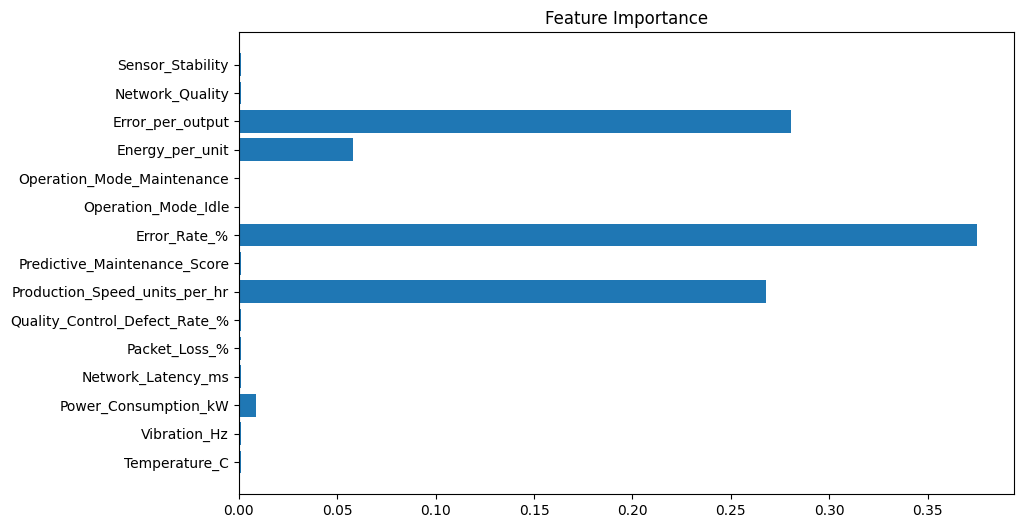

In [15]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

## Prediction Confidence

In [16]:
import numpy as np

probs = rf.predict_proba(X_test)
confidence = np.max(probs, axis=1)

confidence[:10]

array([1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 0.99, 1.  , 1.  ])

## Model Saving

In [17]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

## Machine-Level Insights

In [18]:
df.groupby('Machine_ID')['Efficiency_Status'].mean()

Machine_ID
1     1.173800
2     1.161195
3     1.157421
4     1.166667
5     1.148801
6     1.168046
7     1.161832
8     1.140824
9     1.151180
10    1.156281
11    1.162993
12    1.172379
13    1.159804
14    1.163833
15    1.168722
16    1.174627
17    1.158176
18    1.151649
19    1.174152
20    1.183249
21    1.163743
22    1.151649
23    1.172084
24    1.164315
25    1.161161
26    1.166586
27    1.170158
28    1.158691
29    1.164384
30    1.160077
31    1.148474
32    1.164451
33    1.165644
34    1.163244
35    1.155254
36    1.155875
37    1.171079
38    1.164723
39    1.182639
40    1.150425
41    1.171386
42    1.158990
43    1.149003
44    1.163583
45    1.160096
46    1.152720
47    1.151424
48    1.158892
49    1.158462
50    1.166841
Name: Efficiency_Status, dtype: float64

## Additional Models (Logistic Regression & XGBoost)

In [19]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


##  Model Comparison

In [20]:
from sklearn.metrics import accuracy_score

for name, model in {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}.items():
    pred = model.predict(X_test)
    print(name, accuracy_score(y_test, pred))

Logistic Regression 0.93575
Random Forest 0.99995
XGBoost 0.9993


In [24]:
print(X.columns)

Index(['Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
       'Network_Latency_ms', 'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
       'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score',
       'Error_Rate_%', 'Operation_Mode_Idle', 'Operation_Mode_Maintenance',
       'Energy_per_unit', 'Error_per_output', 'Network_Quality',
       'Sensor_Stability'],
      dtype='object')
